In [15]:
# Librerías básicas
import pandas as pd
import numpy as np
import json
import re
import warnings
warnings.filterwarnings('ignore')

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Librerías de NLP
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Librerías de preprocesamiento y extracción de características
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Librerías de modelado
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

# Métricas de evaluación
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Descargar recursos de NLTK (solo primera vez)
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('averaged_perceptron_tagger')

# Cargar modelo de spaCy
nlp = spacy.load('en_core_web_sm')

print("✅ Todas las librerías importadas correctamente")



✅ Todas las librerías importadas correctamente


In [16]:
# Cargar archivo JSON
with open('../dataset/complaints.json', 'r') as file:
    data = json.load(file)

# Convertir a DataFrame
df = pd.DataFrame(data)

# Mostrar primeras filas
print(f"📊 Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()


📊 Dataset cargado: 78313 filas, 5 columnas


,_index,_type,_id,_score,_source
0,complaint-public-v2,complaint,3211475,0.0,"{'tags': None, 'zip_code': '90301', 'complaint..."
1,complaint-public-v2,complaint,3229299,0.0,"{'tags': 'Servicemember', 'zip_code': '319XX',..."
2,complaint-public-v2,complaint,3199379,0.0,"{'tags': None, 'zip_code': '77069', 'complaint..."
3,complaint-public-v2,complaint,2673060,0.0,"{'tags': None, 'zip_code': '48066', 'complaint..."
4,complaint-public-v2,complaint,3203545,0.0,"{'tags': None, 'zip_code': '10473', 'complaint..."


In [17]:
# ===== DATA PREPARATION =====

# 1. Inspeccionar el dataframe
print("="*80)
print("📊 INSPECCIÓN INICIAL DEL DATAFRAME")
print("="*80)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nPrimeras 5 filas:")
df.head()


📊 INSPECCIÓN INICIAL DEL DATAFRAME
Dimensiones: 78313 filas × 5 columnas

Primeras 5 filas:


,_index,_type,_id,_score,_source
0,complaint-public-v2,complaint,3211475,0.0,"{'tags': None, 'zip_code': '90301', 'complaint..."
1,complaint-public-v2,complaint,3229299,0.0,"{'tags': 'Servicemember', 'zip_code': '319XX',..."
2,complaint-public-v2,complaint,3199379,0.0,"{'tags': None, 'zip_code': '77069', 'complaint..."
3,complaint-public-v2,complaint,2673060,0.0,"{'tags': None, 'zip_code': '48066', 'complaint..."
4,complaint-public-v2,complaint,3203545,0.0,"{'tags': None, 'zip_code': '10473', 'complaint..."


In [18]:
# Expandir la columna '_source' que contiene datos anidados
df = pd.json_normalize(data)

print("="*80)
print("📊 DATAFRAME EXPANDIDO")
print("="*80)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")
    
df.head()


📊 DATAFRAME EXPANDIDO
Dimensiones: 78313 filas × 22 columnas

Columnas disponibles:
  1. _index
  2. _type
  3. _id
  4. _score
  5. _source.tags
  6. _source.zip_code
  7. _source.complaint_id
  8. _source.issue
  9. _source.date_received
  10. _source.state
  11. _source.consumer_disputed
  12. _source.product
  13. _source.company_response
  14. _source.company
  15. _source.submitted_via
  16. _source.date_sent_to_company
  17. _source.company_public_response
  18. _source.sub_product
  19. _source.timely
  20. _source.complaint_what_happened
  21. _source.sub_issue
  22. _source.consumer_consent_provided


,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [19]:
# Ver primeras filas completas
print("="*80)
print("📋 PRIMERAS 5 FILAS DEL DATAFRAME")
print("="*80)
df.head()

📋 PRIMERAS 5 FILAS DEL DATAFRAME


,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [20]:
# Imprimir nombres de todas las columnas
print("="*80)
print("📋 NOMBRES DE COLUMNAS")
print("="*80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


📋 NOMBRES DE COLUMNAS
 1. _index
 2. _type
 3. _id
 4. _score
 5. _source.tags
 6. _source.zip_code
 7. _source.complaint_id
 8. _source.issue
 9. _source.date_received
10. _source.state
11. _source.consumer_disputed
12. _source.product
13. _source.company_response
14. _source.company
15. _source.submitted_via
16. _source.date_sent_to_company
17. _source.company_public_response
18. _source.sub_product
19. _source.timely
20. _source.complaint_what_happened
21. _source.sub_issue
22. _source.consumer_consent_provided


In [21]:
# Renombrar solo la columna crítica para facilitar el trabajo
df = df.rename(columns={
    '_source.complaint_what_happened': 'complains'
})

# Si la columna tiene otro nombre, verificar:
if '_source_complaint_what_happened' in df.columns:
    df = df.rename(columns={
        '_source_complaint_what_happened': 'complains'
    })

print("✅ Columna 'complaint_what_happened' renombrada a 'complains'")
df.head()


✅ Columna 'complaint_what_happened' renombrada a 'complains'


,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,complains,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [22]:
# ===== ANÁLISIS EXHAUSTIVO DE VALORES ÚNICOS =====

print("="*80)
print("🔍 ANÁLISIS DE VALORES ÚNICOS POR COLUMNA")
print("="*80)

# Categorías para clasificar columnas
id_columns = []
low_cardinality = []  # Pocas categorías únicas
high_cardinality = []  # Muchas categorías únicas
text_columns = []

for col in df.columns:
    n_unique = df[col].nunique()
    n_null = df[col].isnull().sum()
    pct_null = (n_null / len(df)) * 100
    total = len(df)
    
    # Clasificar columnas
    if 'id' in col.lower():
        id_columns.append(col)
    elif n_unique <= 20:
        low_cardinality.append(col)
    elif n_unique > 1000:
        high_cardinality.append(col)
    else:
        text_columns.append(col)
    
    print(f"\n{col}")
    print(f"  Valores únicos: {n_unique:,} ({n_unique/total*100:.2f}%)")
    print(f"  Valores nulos: {n_null:,} ({pct_null:.2f}%)")
    print(f"  Valores no nulos: {total - n_null:,}")


🔍 ANÁLISIS DE VALORES ÚNICOS POR COLUMNA

_index
  Valores únicos: 1 (0.00%)
  Valores nulos: 0 (0.00%)
  Valores no nulos: 78,313

_type
  Valores únicos: 1 (0.00%)
  Valores nulos: 0 (0.00%)
  Valores no nulos: 78,313

_id
  Valores únicos: 78,313 (100.00%)
  Valores nulos: 0 (0.00%)
  Valores no nulos: 78,313

_score
  Valores únicos: 1 (0.00%)
  Valores nulos: 0 (0.00%)
  Valores no nulos: 78,313

_source.tags
  Valores únicos: 3 (0.00%)
  Valores nulos: 67,413 (86.08%)
  Valores no nulos: 10,900

_source.zip_code
  Valores únicos: 9,442 (12.06%)
  Valores nulos: 6,757 (8.63%)
  Valores no nulos: 71,556

_source.complaint_id
  Valores únicos: 78,313 (100.00%)
  Valores nulos: 0 (0.00%)
  Valores no nulos: 78,313

_source.issue
  Valores únicos: 154 (0.20%)
  Valores nulos: 0 (0.00%)
  Valores no nulos: 78,313

_source.date_received
  Valores únicos: 3,444 (4.40%)
  Valores nulos: 0 (0.00%)
  Valores no nulos: 78,313

_source.state
  Valores únicos: 62 (0.08%)
  Valores nulos: 1,991

In [23]:
# ===== ANÁLISIS DE COLUMNAS DE BAJA CARDINALIDAD (≤20 valores únicos) =====

print("="*80)
print("📊 DISTRIBUCIÓN DE COLUMNAS DE BAJA CARDINALIDAD")
print("="*80)

# Filtrar solo columnas con pocos valores únicos (excluyendo IDs)
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 20 and 'id' not in col.lower():
        print(f"\n{'='*80}")
        print(f"📋 {col.upper()}")
        print(f"{'='*80}")
        print(f"Valores únicos: {n_unique}")
        print(f"\nDistribución de valores:")
        print(df[col].value_counts())
        print(f"\nValores nulos: {df[col].isnull().sum()}")


📊 DISTRIBUCIÓN DE COLUMNAS DE BAJA CARDINALIDAD

📋 _INDEX
Valores únicos: 1

Distribución de valores:
_index
complaint-public-v2    78313
Name: count, dtype: int64

Valores nulos: 0

📋 _TYPE
Valores únicos: 1

Distribución de valores:
_type
complaint    78313
Name: count, dtype: int64

Valores nulos: 0

📋 _SCORE
Valores únicos: 1

Distribución de valores:
_score
0.0    78313
Name: count, dtype: int64

Valores nulos: 0

📋 _SOURCE.TAGS
Valores únicos: 3

Distribución de valores:
_source.tags
Older American                   6103
Servicemember                    3759
Older American, Servicemember    1038
Name: count, dtype: int64

Valores nulos: 67413

📋 _SOURCE.CONSUMER_DISPUTED
Valores únicos: 3

Distribución de valores:
_source.consumer_disputed
N/A    35683
No     33107
Yes     9523
Name: count, dtype: int64

Valores nulos: 0

📋 _SOURCE.PRODUCT
Valores únicos: 17

Distribución de valores:
_source.product
Mortgage                                                                        2

In [24]:
# ===== ANÁLISIS DE LA COLUMNA DE TEXTO DE QUEJAS =====

# Identificar columna de quejas
complaint_col = None
for col in df.columns:
    if 'complaint' in col.lower() and 'what' in col.lower():
        complaint_col = col
        break

if complaint_col:
    print("="*80)
    print(f"📝 ANÁLISIS DE COLUMNA DE TEXTO: {complaint_col}")
    print("="*80)
    
    # Contar textos vacíos vs no vacíos
    empty_count = (df[complaint_col] == '').sum()
    null_count = df[complaint_col].isnull().sum()
    valid_count = len(df) - empty_count - null_count
    
    print(f"\nTotal de registros: {len(df):,}")
    print(f"Textos válidos (con contenido): {valid_count:,} ({valid_count/len(df)*100:.2f}%)")
    print(f"Textos vacíos (string vacío ''): {empty_count:,} ({empty_count/len(df)*100:.2f}%)")
    print(f"Valores nulos (NaN): {null_count:,} ({null_count/len(df)*100:.2f}%)")
    print(f"Textos inválidos (vacíos + nulos): {empty_count + null_count:,} ({(empty_count + null_count)/len(df)*100:.2f}%)")
    
    # Ejemplos de textos válidos
    print(f"\n📋 EJEMPLOS DE TEXTOS VÁLIDOS:")
    valid_texts = df[df[complaint_col].str.strip() != ''][complaint_col]
    for i, text in enumerate(valid_texts.head(3), 1):
        print(f"\nEjemplo {i}:")
        print(f"{text[:200]}...")
    
    # Estadísticas de longitud
    valid_df = df[df[complaint_col].str.strip() != '']
    valid_df['text_length'] = valid_df[complaint_col].str.len()
    
    print(f"\n📏 ESTADÍSTICAS DE LONGITUD DE TEXTO:")
    print(f"Promedio: {valid_df['text_length'].mean():.0f} caracteres")
    print(f"Mediana: {valid_df['text_length'].median():.0f} caracteres")
    print(f"Mínimo: {valid_df['text_length'].min()} caracteres")
    print(f"Máximo: {valid_df['text_length'].max()} caracteres")
# ===== ANÁLISIS DE COLUMNAS CLAVE PARA NLP =====

print("="*80)
print("🎯 ANÁLISIS DE COLUMNAS CLAVE PARA EL PROYECTO")
print("="*80)

# Buscar columnas importantes
key_columns = {
    'issue': None,
    'product': None,
    'company': None,
    'state': None
}

for key in key_columns.keys():
    for col in df.columns:
        if key in col.lower() and 'id' not in col.lower():
            key_columns[key] = col
            break

# Analizar cada columna clave
for name, col in key_columns.items():
    if col:
        print(f"\n{'='*80}")
        print(f"📊 {name.upper()}: {col}")
        print(f"{'='*80}")
        n_unique = df[col].nunique()
        print(f"Valores únicos: {n_unique}")
        
        if n_unique <= 50:
            print(f"\nDistribución completa:")
            print(df[col].value_counts())
        else:
            print(f"\nTop 15 valores más frecuentes:")
            print(df[col].value_counts().head(15))


🎯 ANÁLISIS DE COLUMNAS CLAVE PARA EL PROYECTO

📊 ISSUE: _source.issue


Valores únicos: 154

Top 15 valores más frecuentes:
_source.issue
Loan modification,collection,foreclosure                        9743
Managing an account                                             7410
Loan servicing, payments, escrow account                        5360
Problem with a purchase shown on your statement                 4055
Account opening, closing, or management                         3879
Deposits and withdrawals                                        3111
Incorrect information on your report                            2714
Closing an account                                              1830
Billing disputes                                                1744
Trouble during payment process                                  1673
Struggling to pay mortgage                                      1552
Other                                                           1514
Application, originator, mortgage broker                        1486
Other features, terms, or problems   

In [25]:
# ===== RESUMEN EJECUTIVO DEL EDA =====

print("="*80)
print("📊 RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO")
print("="*80)

print(f"\n1️⃣ DIMENSIONES DEL DATASET:")
print(f"   Total de registros: {len(df):,}")
print(f"   Total de columnas: {df.shape[1]}")

print(f"\n3️⃣ COLUMNAS CON ALTA NULIDAD (>50%):")
high_null_cols = df.isnull().sum()[df.isnull().sum() / len(df) > 0.5]
if len(high_null_cols) > 0:
    for col, null_count in high_null_cols.items():
        print(f"   {col}: {null_count:,} nulos ({null_count/len(df)*100:.2f}%)")
else:
    print("   Ninguna")

📊 RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO

1️⃣ DIMENSIONES DEL DATASET:
   Total de registros: 78,313
   Total de columnas: 22

3️⃣ COLUMNAS CON ALTA NULIDAD (>50%):
   _source.tags: 67,413 nulos (86.08%)
   _source.company_public_response: 78,309 nulos (99.99%)
   _source.sub_issue: 46,297 nulos (59.12%)


In [26]:
complaint_col = 'complains'

# Registros válidos/inválidos
valid_text = (df[complaint_col].str.strip() != '').sum()
empty_count = (df[complaint_col] == '').sum()
null_count = df[complaint_col].isnull().sum()

print(f"\nTotal de registros: {len(df):,}")
print(f"Textos válidos (con contenido): {valid_text:,} ({valid_text/len(df)*100:.2f}%)")
print(f"Textos vacíos (string vacío ''): {empty_count:,} ({empty_count/len(df)*100:.2f}%)")
print(f"Valores nulos (NaN): {null_count:,} ({null_count/len(df)*100:.2f}%)")
print(f"Textos inválidos (vacíos + nulos): {empty_count + null_count:,} ({(empty_count + null_count)/len(df)*100:.2f}%)")

# Ejemplos de textos válidos
print(f"\n📋 EJEMPLOS DE TEXTOS VÁLIDOS:")
valid_texts = df[df[complaint_col].str.strip() != ''][complaint_col]
for i, text in enumerate(valid_texts.head(3), 1):
    print(f"\nEjemplo {i}:")
    print(f"{text[:200]}...")

# Estadísticas de longitud
valid_df = df[df[complaint_col].str.strip() != '']
valid_df['text_length'] = valid_df[complaint_col].str.len()
print(f"\n📏 ESTADÍSTICAS DE LONGITUD DE TEXTO:")
print(f"Promedio: {valid_df['text_length'].mean():.0f} caracteres")
print(f"Mediana: {valid_df['text_length'].median():.0f} caracteres")
print(f"Mínimo: {valid_df['text_length'].min()} caracteres")
print(f"Máximo: {valid_df['text_length'].max()} caracteres")



Total de registros: 78,313
Textos válidos (con contenido): 21,072 (26.91%)
Textos vacíos (string vacío ''): 57,241 (73.09%)
Valores nulos (NaN): 0 (0.00%)
Textos inválidos (vacíos + nulos): 57,241 (73.09%)

📋 EJEMPLOS DE TEXTOS VÁLIDOS:

Ejemplo 1:
Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. 
In 2018 I wrote to Chase asking for debt verification and what they sent me a ...

Ejemplo 2:
I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgra...

Ejemplo 3:
Chase Card was reported on XX/XX/2019. However, fraudulent application have been submitted my identity without my consent to fraudulently obtain services. Do not extend credit without verifying the id...

📏 ESTADÍSTICAS DE LONGITUD DE TEXTO:
Promedio: 1384 caracteres
Mediana: 983 caracteres
Mínimo: 19 caracteres
Máxi

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78313 entries, 0 to 78312
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   _index                             78313 non-null  object 
 1   _type                              78313 non-null  object 
 2   _id                                78313 non-null  object 
 3   _score                             78313 non-null  float64
 4   _source.tags                       10900 non-null  object 
 5   _source.zip_code                   71556 non-null  object 
 6   _source.complaint_id               78313 non-null  object 
 7   _source.issue                      78313 non-null  object 
 8   _source.date_received              78313 non-null  object 
 9   _source.state                      76322 non-null  object 
 10  _source.consumer_disputed          78313 non-null  object 
 11  _source.product                    78313 non-null  obj

In [28]:
# ===== FUNCIÓN DE FILTRADO INICIAL DE COLUMNAS =====

# Lista de columnas que SÍ se mantendrán
columns_to_keep = [
    '_source.complaint_id',
    '_source.issue',
    '_source.date_received',
    '_source.state',
    '_source.consumer_disputed',
    '_source.product',
    '_source.company_response',
    '_source.submitted_via',
    '_source.sub_product',
    'complains',
    '_source.sub_issue'
]

# Filtra el dataframe original manteniendo solo estas columnas
df_filtered = df[columns_to_keep].copy()
print("="*80)
print("📊 DATAFRAME FILTRADO INICIAL (SOLO COLUMNAS RELEVANTES)")
print("="*80)
print(f"Dimensiones: {df_filtered.shape[0]} filas × {df_filtered.shape[1]} columnas")
print(f"\nNombres de columnas:")
for i, col in enumerate(df_filtered.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\nPrimeras 3 filas:")
print(df_filtered.head(3))

print(f"\nValores nulos por columna:")
print(df_filtered.isnull().sum())


📊 DATAFRAME FILTRADO INICIAL (SOLO COLUMNAS RELEVANTES)
Dimensiones: 78313 filas × 11 columnas

Nombres de columnas:
 1. _source.complaint_id
 2. _source.issue
 3. _source.date_received
 4. _source.state
 5. _source.consumer_disputed
 6. _source.product
 7. _source.company_response
 8. _source.submitted_via
 9. _source.sub_product
10. complains
11. _source.sub_issue

Primeras 3 filas:
  _source.complaint_id                       _source.issue  \
0              3211475   Attempts to collect debt not owed   
1              3229299     Written notification about debt   
2              3199379  Other features, terms, or problems   

       _source.date_received _source.state _source.consumer_disputed  \
0  2019-04-13T12:00:00-05:00            CA                       N/A   
1  2019-05-01T12:00:00-05:00            GA                       N/A   
2  2019-04-02T12:00:00-05:00            TX                       N/A   

               _source.product _source.company_response _source.submitted_

In [29]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78313 entries, 0 to 78312
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   _source.complaint_id       78313 non-null  object
 1   _source.issue              78313 non-null  object
 2   _source.date_received      78313 non-null  object
 3   _source.state              76322 non-null  object
 4   _source.consumer_disputed  78313 non-null  object
 5   _source.product            78313 non-null  object
 6   _source.company_response   78313 non-null  object
 7   _source.submitted_via      78313 non-null  object
 8   _source.sub_product        67742 non-null  object
 9   complains                  78313 non-null  object
 10  _source.sub_issue          32016 non-null  object
dtypes: object(11)
memory usage: 6.6+ MB


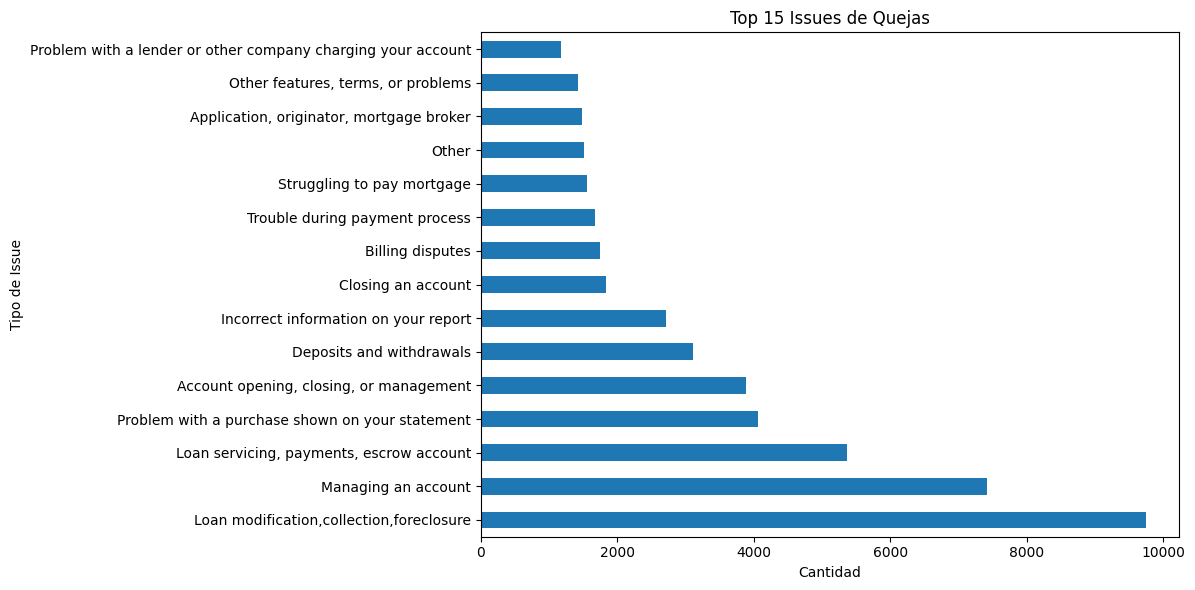

In [30]:
plt.figure(figsize=(12,6))
df_filtered['_source.issue'].value_counts().head(15).plot(kind='barh')
plt.title('Top 15 Issues de Quejas')
plt.xlabel('Cantidad')
plt.ylabel('Tipo de Issue')
plt.tight_layout()
plt.show()


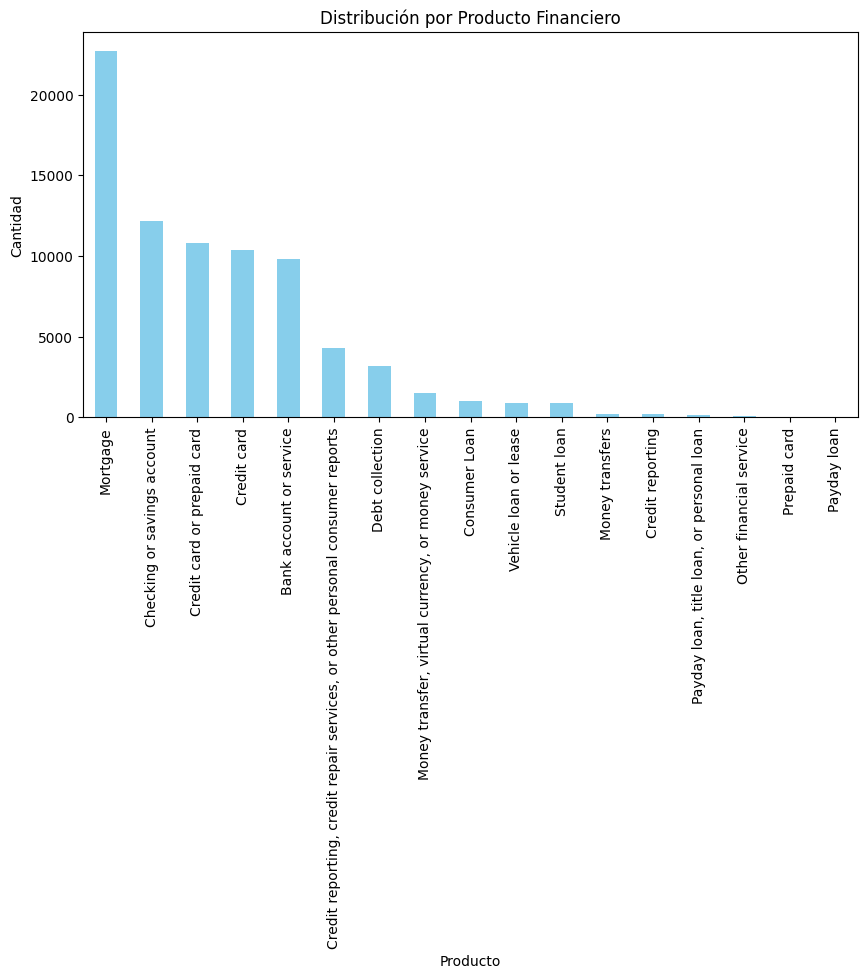

In [31]:
plt.figure(figsize=(10,5))
df_filtered['_source.product'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribución por Producto Financiero')
plt.xlabel('Producto')
plt.ylabel('Cantidad')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


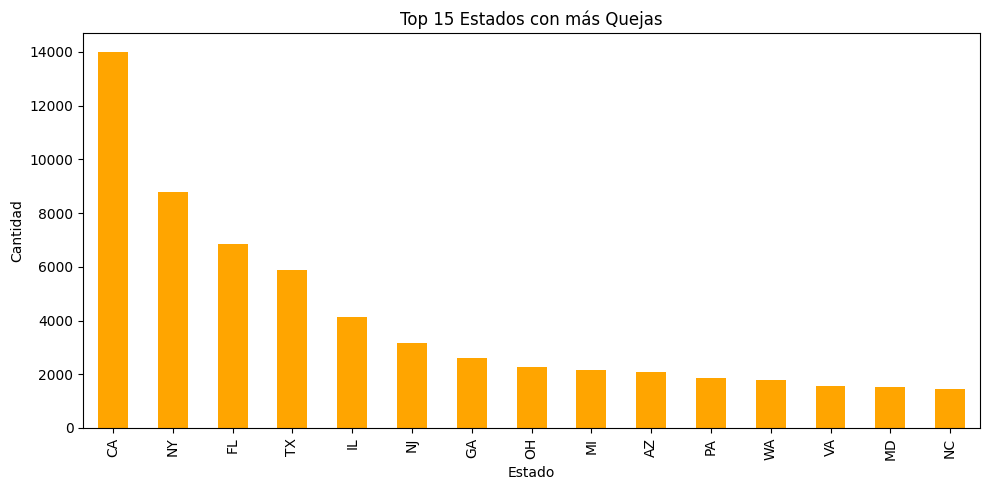

In [32]:
plt.figure(figsize=(10,5))
df_filtered['_source.state'].value_counts().head(15).plot(kind='bar', color='orange')
plt.title('Top 15 Estados con más Quejas')
plt.xlabel('Estado')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()


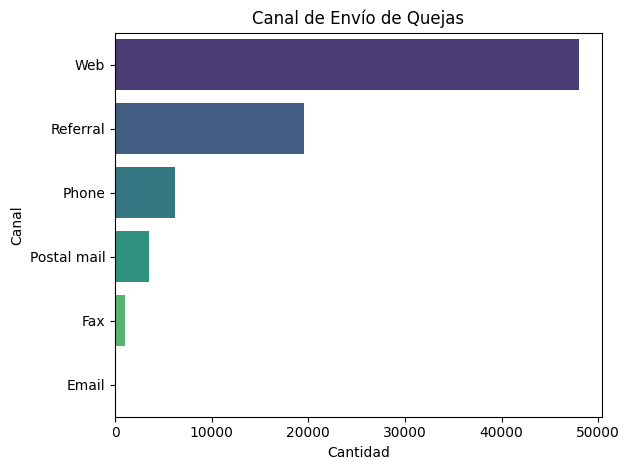

In [33]:
sns.countplot(y=df_filtered['_source.submitted_via'], order=df_filtered['_source.submitted_via'].value_counts().index, palette='viridis')
plt.title('Canal de Envío de Quejas')
plt.xlabel('Cantidad')
plt.ylabel('Canal')
plt.tight_layout()
plt.show()


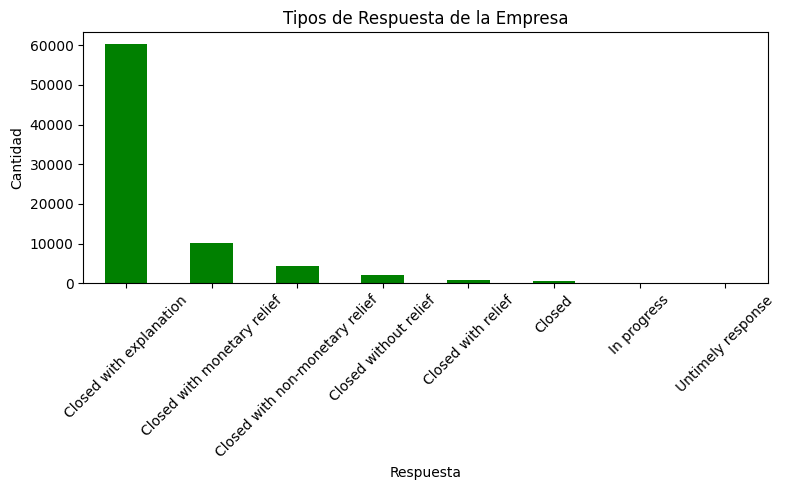

In [34]:
plt.figure(figsize=(8,5))
df_filtered['_source.company_response'].value_counts().plot(kind='bar', color='green')
plt.title('Tipos de Respuesta de la Empresa')
plt.xlabel('Respuesta')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


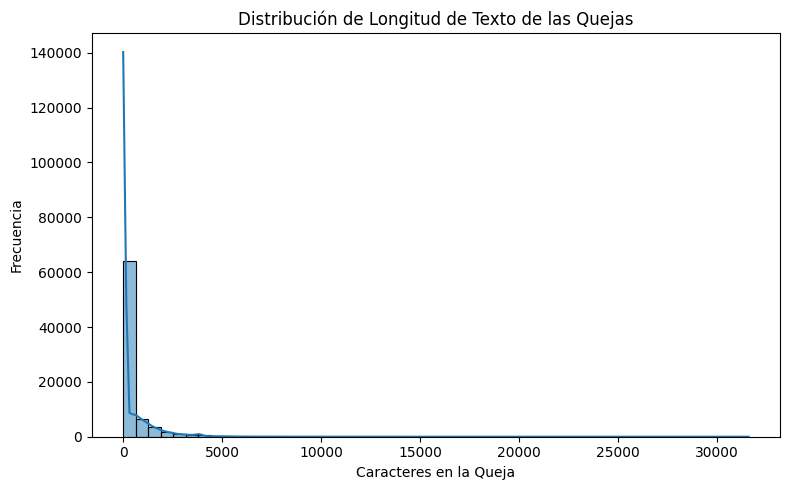

In [35]:
df_filtered['complain_length'] = df_filtered['complains'].str.len()
plt.figure(figsize=(8,5))
sns.histplot(df_filtered['complain_length'], bins=50, kde=True)
plt.title('Distribución de Longitud de Texto de las Quejas')
plt.xlabel('Caracteres en la Queja')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


In [36]:
# Lista de columnas dudosas a analizar
columns_pending = ['_source.sub_issue', '_source.sub_product', '_source.state']

for col in columns_pending:
    print(f"\n{'='*80}")
    print(f"Análisis de columna: {col}")
    print(f"{'='*80}")
    
    # Valores nulos
    null_count = df_filtered[col].isnull().sum()
    null_pct = null_count / len(df_filtered) * 100
    print(f"Valores nulos: {null_count} ({null_pct:.2f}%)")
    
    # Valores únicos
    unique_count = df_filtered[col].nunique(dropna=True)
    print(f"Valores únicos (sin nulos): {unique_count}")
    
    # Distribución de los 10 valores más frecuentes
    print("Top 10 valores más frecuentes:")
    print(df_filtered[col].value_counts(dropna=True).head(10))
    
    # ¿Es útil comparar con la variable target/producto?
    if col != 'complains':
        print("\nEjemplo de tabla cruzada con producto:")
        print(pd.crosstab(df_filtered[col], df_filtered['_source.product']).head())



Análisis de columna: _source.sub_issue
Valores nulos: 46297 (59.12%)
Valores únicos (sin nulos): 205
Top 10 valores más frecuentes:
_source.sub_issue
Credit card company isn't resolving a dispute about a purchase on your statement    2904
Deposits and withdrawals                                                            2759
Company closed your account                                                         2020
Problem using a debit or ATM card                                                   1613
Card was charged for something you did not purchase with the card                   1056
Information belongs to someone else                                                 1030
Transaction was not authorized                                                       974
Credit inquiries on your report that you don't recognize                             847
Banking errors                                                                       831
Account status incorrect                        

## Preprocesamiento

In [37]:
import re
import string

def clean_text(text):
    # A minúsculas
    text = text.lower()
    # Quitar texto en corchetes, signos de puntuación, números, y caracteres especiales
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(rf"[{string.punctuation}]", '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

df_filtered['complain_clean'] = df_filtered['complains'].apply(clean_text)
print(df_filtered[['complains','complain_clean']].head())


                                           complains  \
0                                                      
1  Good morning my name is XXXX XXXX and I apprec...   
2  I upgraded my XXXX XXXX card in XX/XX/2018 and...   
3                                                      
4                                                      

                                      complain_clean  
0                                                     
1  good morning my name is xxxx xxxx and i apprec...  
2  i upgraded my xxxx xxxx card in xxxx and was t...  
3                                                     
4                                                     


In [38]:
def lemmatize_and_only_nouns(text):
    doc = nlp(text)
    # Extraer sólo si pos_ (parte de la oración) es 'NOUN'
    return ' '.join([token.lemma_ for token in doc if token.pos_ == 'NOUN'])

df_filtered['complain_nouns'] = df_filtered['complain_clean'].apply(lemmatize_and_only_nouns)
print(df_filtered[['complain_clean','complain_nouns']].head())

                                      complain_clean  \
0                                                      
1  good morning my name is xxxx xxxx and i apprec...   
2  i upgraded my xxxx xxxx card in xxxx and was t...   
3                                                      
4                                                      

                                      complain_nouns  
0                                                     
1  morning name stop service debt verification st...  
2  card agent anniversary date agent information ...  
3                                                     
4                                                     
